In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
plt.style.use('./deeplearning.mplstyle')
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from lab_utils_common import dlc
from lab_coffee_utils import load_coffee_data, plt_roast, plt_prob, plt_layer, plt_network, plt_output_unit
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)


In [2]:
X, Y = load_coffee_data()
print(X.shape, Y.shape)

(200, 2) (200, 1)


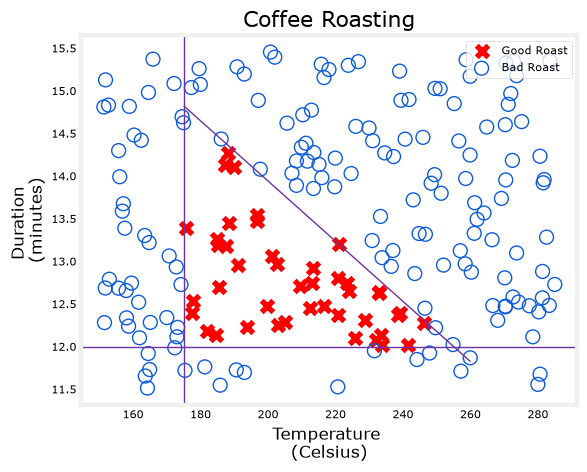

In [3]:
plt_roast(X,Y)

In [4]:
print(f"Temperature Max, Min Pre Normalization: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):0.2f}")
print(f"Duration Max, Min Pre Normalization: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):0.2f}")
norm_l = tf.keras.layers.Normalization(axis=-1)
norm_l.adapt(X) # Learns mean, variance
Xn = norm_l(X)
print(f"Temperature Max, Min Post Normalization: {np.max(Xn[:,0]):0.2f}, {np.min(Xn[:,0]):0.2f}")
print(f"Duration Max, Min Post Normalization: {np.max(Xn[:,1]):0.2f}, {np.min(Xn[:,1]):0.2f}")

Temperature Max, Min Pre Normalization: 284.99, 151.32
Duration Max, Min Pre Normalization: 15.45, 11.51
Temperature Max, Min Post Normalization: 1.66, -1.69
Duration Max, Min Post Normalization: 1.79, -1.70


In [5]:
Xt = np.tile(Xn,(1000,1))
Yt= np.tile(Y,(1000,1))   
print(Xt.shape, Yt.shape)   

(200000, 2) (200000, 1)


In [6]:
tf.random.set_seed(1234) # applied to acheiev consistent results

model = Sequential([
    tf.keras.Input(shape=(2,)),
    Dense(3, activation = 'sigmoid', name = 'Layer1'),
    Dense(1, activation = 'sigmoid', name = 'Layer2')
])

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Layer1 (Dense)                  │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer2 (Dense)                  │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
L1_num_params = 2 * 3 + 3   # W1 parameters  + b1 parameters
L2_num_params = 3 * 1 + 1   # W2 parameters  + b2 parameters
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params  )

L1 params =  9 , L2 params =  4


In [9]:
W1, b1 = model.get_layer("Layer1").get_weights()
W2, b2 = model.get_layer("Layer2").get_weights()
print(f"W1{W1.shape}:\n", W1, f"\nb1{b1.shape}:", b1)
print(f"W2{W2.shape}:\n", W2, f"\nb2{b2.shape}:", b2)

W1(2, 3):
 [[-0.26 -0.04  0.27]
 [ 0.28  0.3   0.3 ]] 
b1(3,): [0. 0. 0.]
W2(3, 1):
 [[-0.96]
 [ 0.45]
 [-1.1 ]] 
b2(1,): [0.]


In [10]:
from tensorflow.keras.optimizers import Optimizer
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.1),
)

model.fit(
    Xt, Yt,
    epochs = 10,
)

Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - loss: 0.1468
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - loss: 0.1345
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - loss: 0.1310
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 35s 6ms/step - loss: 0.1282
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - loss: 0.1263
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 35s 6ms/step - loss: 0.1249
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - loss: 0.1239
Epoch 8/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 42s 6ms/step - loss: 0.1230
Epoch 9/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 37s 6ms/step - loss: 0.1225
Epoch 10/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 37s 6ms/step - loss: 0.1219


In [11]:
W1, b1 = model.get_layer("Layer1").get_weights()
W2, b2 = model.get_layer("Layer2").get_weights()
print("W1:\n", W1, "\nb1:", b1)
print("W2:\n", W2, "\nb2:", b2)

W1:
 [[-5.93 23.19 70.53]
 [47.39  5.96 55.5 ]] 
b1: [-48.34  30.45   2.53]
W2:
 [[ -51.87]
 [  10.9 ]
 [-101.45]] 
b2: [-9.27]


In [12]:
# After finishing the lab later, you can re-run all 
# cells except this one to see if your trained model
# gets the same results.

# Set weights from a previous run. 
W1 = np.array([
    [-8.94,  0.29, 12.89],
    [-0.17, -7.34, 10.79]] )
b1 = np.array([-9.87, -9.28,  1.01])
W2 = np.array([
    [-31.38],
    [-27.86],
    [-32.79]])
b2 = np.array([15.54])

# Replace the weights from your trained model with
# the values above.
model.get_layer("Layer1").set_weights([W1,b1])
model.get_layer("Layer2").set_weights([W2,b2])

In [13]:
# Check if the weights are successfully replaced
W1, b1 = model.get_layer("Layer1").get_weights()
W2, b2 = model.get_layer("Layer2").get_weights()
print("W1:\n", W1, "\nb1:", b1)
print("W2:\n", W2, "\nb2:", b2)

W1:
 [[-8.94  0.29 12.89]
 [-0.17 -7.34 10.79]] 
b1: [-9.87 -9.28  1.01]
W2:
 [[-31.38]
 [-27.86]
 [-32.79]] 
b2: [15.54]


In [14]:
X_test = np.array([
    [200,13.9], # Posititve example
    [200,17]    # Negative example
])
X_testn = norm_l(X_test)
predictions = model.predict(X_testn)
print("predictions = \n", predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
predictions = 
 [[9.63e-01]
 [3.03e-08]]


In [15]:
yhat = np.zeros_like(predictions)
for i in range(len(predictions)):
    if predictions[i] >= 0.5 :
        yhat[i] = 1
    else:
        yhat[i] = 0
print(f"decisions = \n {yhat}")        


decisions = 
 [[1.]
 [0.]]


In [16]:
yhat = (predictions >= 0.5).astype(int)
print(f"decisions = \n{yhat}")

decisions = 
[[1]
 [0]]


In [17]:
yhat = (predictions >= 0.5).astype(int)
print(f"decisions = \n{yhat}")

decisions = 
[[1]
 [0]]


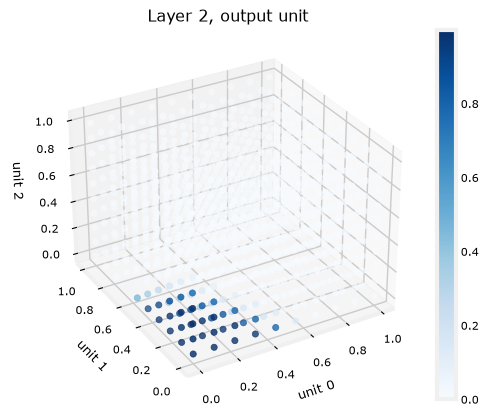

In [18]:
plt_output_unit(W2,b2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242

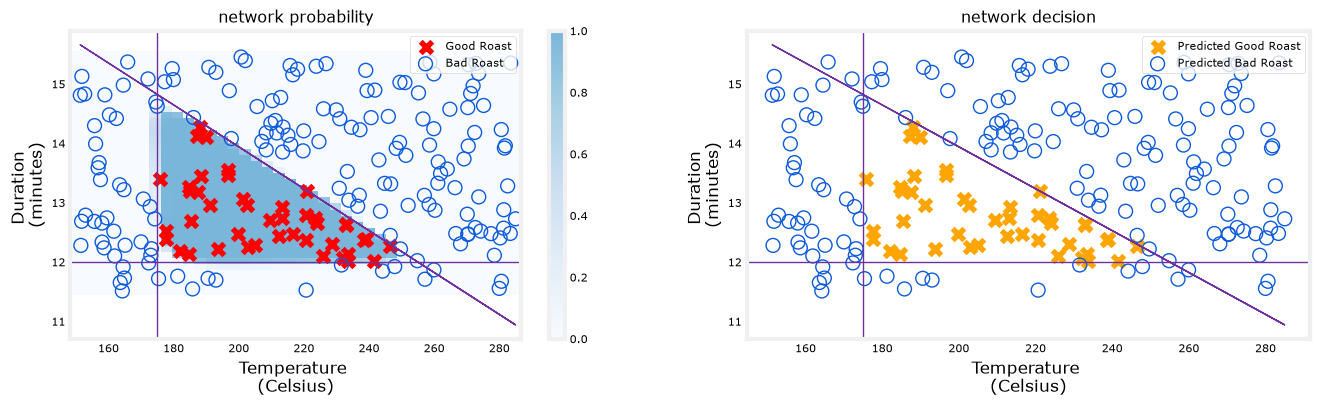

In [19]:
netf= lambda x : model.predict(norm_l(x))
plt_network(X,Y,netf)
